In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

In [6]:
np.random.seed(42)
n = 300
data = pd.DataFrame({
    "age": np.random.randint(18, 60, n),
    "salary": np.random.randint(20000, 100000, n),
    "balance": np.random.randint(-10000, 10000, n)
})
#create binary target
data["churn"] = (
    (data["balance"] > 5000) |
    (data["salary"] < 40000)
).astype(int)
data.head()

,age,salary,balance,churn
0,56,59790,9760,1
1,46,25600,-4355,1
2,32,60764,9870,1
3,25,94543,9968,1
4,38,65714,-412,0


In [7]:
print(data.shape)
print(data.info)
print(data.describe)
print(data['churn'].value_counts())



(300, 4)
<bound method DataFrame.info of      age  salary  balance  churn
0     56   59790     9760      1
1     46   25600    -4355      1
2     32   60764     9870      1
3     25   94543     9968      1
4     38   65714     -412      0
..   ...     ...      ...    ...
295   51   41732     8378      1
296   38   50354     4231      0
297   47   33843    -6510      1
298   50   91726     -690      0
299   45   37640    -2016      1

[300 rows x 4 columns]>
<bound method NDFrame.describe of      age  salary  balance  churn
0     56   59790     9760      1
1     46   25600    -4355      1
2     32   60764     9870      1
3     25   94543     9968      1
4     38   65714     -412      0
..   ...     ...      ...    ...
295   51   41732     8378      1
296   38   50354     4231      0
297   47   33843    -6510      1
298   50   91726     -690      0
299   45   37640    -2016      1

[300 rows x 4 columns]>
churn
0    168
1    132
Name: count, dtype: int64


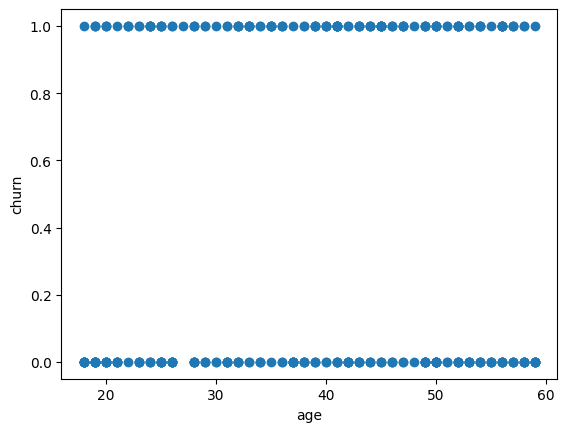

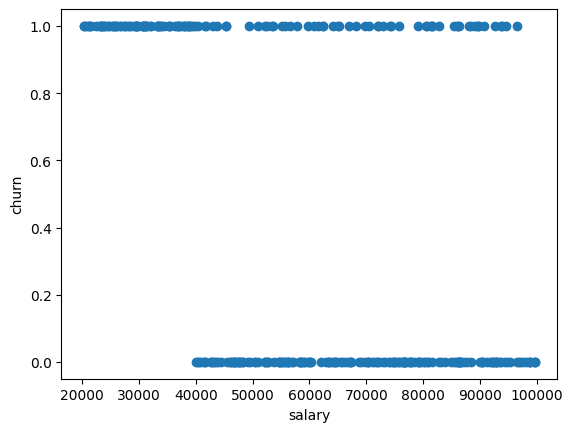

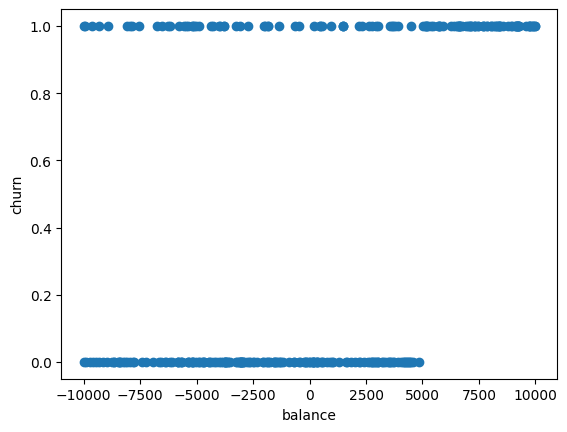

In [11]:
feature = ["age", "salary", "balance"]
for colk in feature:
    plt.figure()
    plt.scatter(data[colk], data["churn"])
    plt.xlabel(colk)
    plt.ylabel("churn")
    plt.show()

In [13]:
X = data[["age", "salary", "balance"]]
y = data["churn"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [23]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [25]:
print("accuracy:", accuracy_score(y_test, y_pred))
print("confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("classification Report:\n", classification_report(y_test, y_pred))
print("roc_auc_score:", roc_auc_score(y_test, y_prob))

accuracy: 0.85
confusion Matrix:
 [[29  5]
 [ 4 22]]
classification Report:
               precision    recall  f1-score   support

           0       0.88      0.85      0.87        34
           1       0.81      0.85      0.83        26

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60

roc_auc_score: 0.9536199095022624


In [32]:
coeff_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
})
print(coeff_df)

   feature  coefficient
0      age    -0.000667
1   salary    -0.000077
2  balance     0.000313


In [34]:
new_data = pd.DataFrame({
    "age" :[35],
    "salary": [70000], # Added a placeholder value for salary
    "balance": [150000] # Changed semicolon to colon
})
print("churn pradiction:", model.predict(new_data)[0])
print("probalbility:", model.predict_proba(new_data)[0][1])

churn pradiction: 1
probalbility: 1.0
